# AIDL – Assessment Dataset Loader

**MSc Applied Artificial Intelligence — AI and Deep Learning Module**  
**WMG, University of Warwick — 2025/26**

---

This notebook provides suggested Datasets for the AIDL assessment.

The notebook will download and preview the three datasets used in the assessment:

| Dataset | Task |
|------|------|
| **Fashion-MNIST** | Image Classification |
| **Heart Disease (Cleveland)** | Tabular Classification |
| **Amazon Electronics Reviews** | Text Sentiment Analysis |

---

## What you should do

Run each section sequentially to:

1. **Download the dataset you would like to explore**
2. **Load it into Python**
3. **Inspect the data structure**
4. **Verify that it works correctly**

You can then reuse the loading code in your **own model notebooks**.

---

## Environment Requirements

According to the dataset chosen, this notebook might require the following libraries:

- `torch`
- `torchvision`
- `pandas`
- `matplotlib`
- `datasets`
- `numpy`

If you are using **Google Colab**, most libraries are already installed.

If running locally in a `venv`, install them with:

```python
python -m pip install torch torchvision pandas matplotlib datasets

# 2. Heart Disease Dataset

This dataset contains **clinical measurements used to predict the presence of heart disease**.

The version used in machine learning research is the **Cleveland Heart Disease dataset**, which is part of the larger UCI Heart Disease database.

Although the full database contains **76 attributes**, most studies use **a subset of 14 key attributes**, which we will also use in this module.

These attributes include:

- demographic data
- clinical test results
- exercise measurements
- cardiovascular indicators

The target variable indicates **whether the patient has heart disease**.

Values range from:

- **0 → no disease**
- **1–4 → presence of disease**

For machine learning experiments, this is usually simplified to:

- **0 → No Heart Disease**
- **1 → Heart Disease Present**

---

## What the next cell does

The following code will:

1. Download the dataset from a public repository
2. Load it using **Pandas**
3. Display the first few rows
4. Allow you to inspect the features

# README: How to Run This Notebook

### Prerequisites
Ensure you have the following Python libraries installed:
`pandas`, `numpy`, `torch`, `sklearn`, `matplotlib`

### Execution Order
1. **Section 1 & 2**: Run these cells to download the Cleveland Heart Disease dataset and perform data cleaning. This step is critical as it handles missing '?' values and normalises clinical features.
2. **Section 3**: Run this cell to define the `HeartDiseaseANN` class.
3. **Section 4**: This initiates the 50-epoch training loop.
4. **Section 5 & 6**: These cells evaluate the model and compare it against the Random Forest baseline.

### Note on Hardware
This notebook is designed to run efficiently on a standard **CPU**. GPU acceleration (T4) is not required due to the small scale of the dataset.

## 1. Data Loading and Initial Inspection

In this section, we import the necessary libraries and load the Cleveland Heart Disease dataset.

This dataset contains 14 clinical attributes used to predict the presence of coronary artery disease.

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Direct link to the raw data
url = "https://raw.githubusercontent.com/dataprofessor/data/master/heart-disease-cleveland.csv"

df = pd.read_csv(url)

df.columns = df.columns.str.strip()

# Display the first 5 rows
print("Heart Disease Dataset Preview:")
print(df.head())

Heart Disease Dataset Preview:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca thal  diagnosis  
0  0.0  6.0          0  
1  3.0  3.0          2  
2  2.0  7.0          1  
3  0.0  3.0          0  
4  0.0  3.0          0  


### 1.5 Exploratory Data Analysis (EDA)
Before preprocessing, it's crucial to understand the distribution of our target variable (`diagnosis`).

In this raw dataset, `0` indicates no disease, while values `1` through `4` indicate varying levels of heart disease. I will temporarily group them to check if the dataset is balanced.

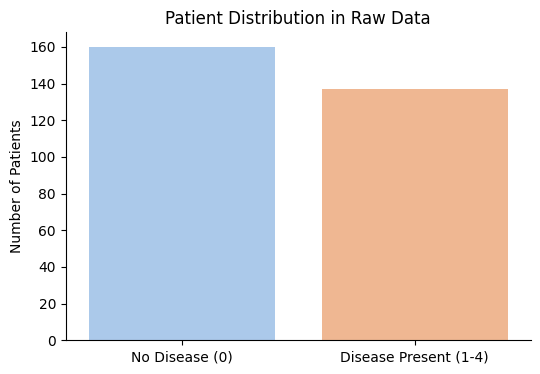

Total patients: 297


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary column just for visualization
temp_target = df['diagnosis'].apply(lambda x: 'Disease Present (1-4)' if x > 0 else 'No Disease (0)')
plt.figure(figsize=(6, 4))

# Updated seaborn syntax to avoid FutureWarning
sns.countplot(x=temp_target, hue=temp_target, palette='pastel', legend=False)

plt.title('Patient Distribution in Raw Data')
plt.xlabel('')
plt.ylabel('Number of Patients')
sns.despine()
plt.show()

print(f"Total patients: {len(df)}")

## 2. Data Preprocessing

Deep learning models require carefully formatted data. According to the dataset dictionary, the target variable (`diagnosis`) ranges from 0 to 4. For this binary classification task, we will simplify this to `0` (No Heart Disease) and `1` (Heart Disease Present).

Furthermore, we must standardise the numerical features. Clinical measurements like cholesterol (`chol`) and age (`age`) operate on completely different scales. Standardisation ensures that no single feature artificially dominates the network's weight updates, leading to faster and more stable convergence.

This ensures that the model evaluation is truly representative of its performance on unseen future patients.

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Clean hidden spaces in column names
df.columns = df.columns.str.strip()
print("1. Column names cleaned:", df.columns.tolist())

# Replace '?' with NaN and drop to avoid ValueError during scaling
df = df.replace('?', np.nan)
df = df.dropna()

# Cast the entire dataframe to float to ensure no strings remain in the dataset
df = df.astype(float)
print("2. Missing values handled. Current valid rows:", len(df))

# Binarize target (0 = no disease, 1 = disease)
df['diagnosis'] = df['diagnosis'].apply(lambda x: 1.0 if x > 0.0 else 0.0)
X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

# Split data (stratify to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features (fit only on train to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

# Create DataLoader (small batch size of 16 due to dataset size)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print("3. Data preprocessing completed successfully! X_train_tensor shape:", X_train_tensor.shape)

1. Column names cleaned: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'diagnosis']
2. Missing values handled. Current valid rows: 297
3. Data preprocessing completed successfully! X_train_tensor shape: torch.Size([237, 13])


## 3. Model Architecture Design

For this structured tabular dataset (13 input features), a Feedforward Artificial Neural Network (ANN) is highly suitable.

Design Decisions:
1. Layers: A shallow architecture with two hidden layers (32 and 16 neurons) prevents overfitting on this small dataset.
2. Activation: ReLU (Rectified Linear Unit) is used to introduce non-linearity.
3. Regularisation: A Dropout layer (p=0.2) randomly zeroes out 20% of the
neurons during training, which forces the network to learn robust features rather than relying on specific pathways.
4. Output Logits: The model outputs raw scores (logits) instead of probabilities. This approach, combined with the loss function used later, improves numerical stability during backpropagation.

In [ ]:
import torch.nn as nn

class HeartDiseaseANN(nn.Module):
    def __init__(self, input_dim):
        super(HeartDiseaseANN, self).__init__()

       # Network architecture: input_dim -> 32 -> 16 -> 1
        self.layer1 = nn.Linear(input_dim, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.layer2 = nn.Linear(32, 16)

      # Raw logit output (Sigmoid is handled by BCEWithLogitsLoss later)
        self.output_layer = nn.Linear(16, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

# Instantiate the model
input_dim = X_train_scaled.shape[1]
model = HeartDiseaseANN(input_dim)

print("Model Architecture:")
print(model)

Model Architecture:
HeartDiseaseANN(
  (layer1): Linear(in_features=13, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=32, out_features=16, bias=True)
  (output_layer): Linear(in_features=16, out_features=1, bias=True)
)


## 4. Model Training
We compile the model using the `Adam` optimiser for efficient gradient descent.

The loss function chosen is `BCEWithLogitsLoss` (Binary Cross Entropy). This is mathematically more stable than manually applying a Sigmoid activation followed by standard BCELoss in PyTorch.

Given the small size of the Cleveland dataset (297 rows), a small batch size of 16 was selected to allow more frequent weight updates per epoch, helping the model converge more efficiently on limited data.

In [ ]:
import torch.optim as optim

# Define Loss function and Optimiser
criterion = nn.BCEWithLogitsLoss()
# Learning rate set to 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop parameters
epochs = 50
train_losses = []

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss:.4f}')

print("Training Complete.")

Starting Training...
Epoch [10/50], Loss: 0.4121
Epoch [20/50], Loss: 0.3460
Epoch [30/50], Loss: 0.3052
Epoch [40/50], Loss: 0.2869
Epoch [50/50], Loss: 0.2683
Training Complete.


## 5. Evaluation and Reflection
To evaluate the model's performance in a real-world healthcare context, accuracy alone is insufficient.
We must look at the **Confusion Matrix** and **Recall (Sensitivity)**.

In medical diagnosis, a False Negative (failing to identify a patient who actually has heart disease) is much more dangerous than a False Positive.

We use a default threshold of 0.5 to classify patients. In practice, this threshold could be tuned to further increase sensitivity (Recall) based on the hospital's tolerance for false negatives.

In [ ]:
# Import the required evaluation metrics from scikit-learn and pandas for the confusion matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

model.eval()

with torch.no_grad():
    test_outputs = model(X_test_tensor)
    predicted_probs = torch.sigmoid(test_outputs)

# Apply sigmoid and set 0.5 threshold for classification
    predicted_classes = (predicted_probs >= 0.5).float()

y_true = y_test_tensor.numpy()
y_pred = predicted_classes.numpy()

# Print detailed evaluation metrics
print("--- Evaluation Metrics ---")
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['No Disease (0)', 'Disease (1)']))

print("Confusion Matrix:")

conf_mat = confusion_matrix(y_true, y_pred)
conf_df = pd.DataFrame(conf_mat,
                       index=['Actual: No Disease', 'Actual: Disease'],
                       columns=['Predicted: No', 'Predicted: Yes'])
display(conf_df)

--- Evaluation Metrics ---
Overall Accuracy: 0.8167

Classification Report:
                precision    recall  f1-score   support

No Disease (0)       0.82      0.84      0.83        32
   Disease (1)       0.81      0.79      0.80        28

      accuracy                           0.82        60
     macro avg       0.82      0.81      0.82        60
  weighted avg       0.82      0.82      0.82        60

Confusion Matrix:


,Predicted: No,Predicted: Yes
Actual: No Disease,27,5
Actual: Disease,6,22


## 6. Baseline Comparison: Traditional Machine Learning
To critically evaluate the deep learning model as required in Part 2 of this assessment, we must compare its performance against a traditional machine learning algorithm.

Here, we implement a **Random Forest Classifier** using the exact same preprocessed dataset (Cleveland Heart Disease dataset).

Random Forest is an ensemble learning method that constructs multiple decision trees. It is highly effective for structured tabular data, handles non-linear relationships well, and generally requires less computational power and hyperparameter tuning compared to Artificial Neural Networks (ANN).

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Init Random Forest (100 trees for stability)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
print("Training Random Forest model...")
rf_model.fit(X_train_scaled, y_train)

# Predict on test set
rf_predictions = rf_model.predict(X_test_scaled)
print("\n--- Random Forest Evaluation Metrics ---")
print(f"Overall Accuracy: {accuracy_score(y_test, rf_predictions):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, rf_predictions, target_names=['No Disease (0)', 'Disease (1)']))

print("Confusion Matrix:")
rf_conf_mat = confusion_matrix(y_test, rf_predictions)
rf_conf_df = pd.DataFrame(rf_conf_mat,
                          index=['Actual: No Disease', 'Actual: Disease'],
                          columns=['Predicted: No', 'Predicted: Yes'])
display(rf_conf_df)

Training Random Forest model...

--- Random Forest Evaluation Metrics ---
Overall Accuracy: 0.8667

Classification Report:
                precision    recall  f1-score   support

No Disease (0)       0.85      0.91      0.88        32
   Disease (1)       0.88      0.82      0.85        28

      accuracy                           0.87        60
     macro avg       0.87      0.86      0.87        60
  weighted avg       0.87      0.87      0.87        60

Confusion Matrix:


,Predicted: No,Predicted: Yes
Actual: No Disease,29,3
Actual: Disease,5,23
